# Substance Use Treatment Dropout Prediction with Explainable AI (TEDS Dataset)

**Author:** *Dylan Camas*
**Dataset:** Treatment Episode Data Set (TEDS) — SAMHSA
**Goal:** Predict whether a patient will fail to complete substance use / mental health treatment, and explain *why* using SHAP.

---

## 1. Project Overview

Treatment dropout is one of the biggest challenges in behavioral health and substance use treatment programs. Patients who leave treatment early (against professional advice, terminated, or otherwise fail to complete) have substantially worse outcomes — higher relapse rates, higher rates of re-hospitalization, and higher long-term costs to the healthcare system.

This project builds an **end-to-end, production-style machine learning pipeline** that:

1. Ingests and cleans real-world administrative treatment data (TEDS).
2. Performs rigorous exploratory data analysis (EDA) to understand dropout drivers.
3. Engineers features that capture demographic, clinical, and treatment-history signal.
4. Trains and tunes multiple classification models (Logistic Regression → Gradient Boosted Trees).
5. Evaluates models using metrics appropriate for **imbalanced, clinically-relevant** classification.
6. Explains model predictions using **SHAP** (SHapley Additive exPlanations), at both the global and individual-patient level.
7. Performs structured error analysis, including a discussion of fairness/bias risks.
8. Sketches a deployment path (FastAPI + joblib) for how this model could be used in a real clinical operations setting.

This notebook is designed as a **portfolio-quality deliverable** for Data Scientist / ML Engineer / AI Engineer roles — it favors clarity, reproducibility, and clinical/business framing over black-box modeling.

> ⚠️ **Ethical note:** This is a demonstration project using administrative (not clinical-grade) data. A model like this should never be used to *deny* care or *flag* patients punitively — its appropriate use is to help treatment programs proactively allocate retention resources (case management, reminder calls, transportation support, etc.) to patients at elevated dropout risk.

---

## 2. Business Problem

**Stakeholder:** Clinical operations / program directors at outpatient and residential substance use treatment facilities.

**Problem statement:** Treatment programs have limited staff time for proactive patient outreach (extra check-ins, transportation assistance, motivational interviewing sessions, peer-support referrals). Today, this outreach is either applied uniformly (inefficient) or reactively, after a patient has already disengaged (too late).

**Proposed solution:** A predictive model that scores each patient's *dropout risk* at, or shortly after, treatment admission — using only information available at that point in time — so that case managers can prioritize outreach toward the patients most likely to drop out.

**Success metrics:**
- **Recall on the dropout class** (catching at-risk patients matters more than catching everyone perfectly) balanced against
- **Precision** (so outreach resources aren't wasted on false alarms), summarized via **F1**, **ROC-AUC**, and **PR-AUC** (most informative under class imbalance).
- **Interpretability**: clinical staff must be able to understand *why* a patient was flagged, hence the heavy emphasis on Explainable AI (XAI) in this notebook.

---

## 3. Dataset Description

The **Treatment Episode Data Set – Discharges (TEDS-D)**, published annually by SAMHSA (Substance Abuse and Mental Health Services Administration), records de-identified, episode-level information for discharges from substance use treatment facilities that report to state administrative data systems.

Typical fields include (exact column names vary slightly by release year — see the flexible column-mapping logic in Section 4):

| Category | Example Fields |
|---|---|
| Demographics | `AGE`, `GENDER`/`SEX`, `RACE`, `ETHNIC`, `MARSTAT`, `EDUC` |
| Treatment context | `SERVICES` (treatment setting), `LOS` (length of stay), `NOPRIOR` (prior treatment episodes), `PSOURCE` (referral source) |
| Substance use | `SUB1`/`SUB2`/`SUB3` (primary/secondary/tertiary substance), `FREQ1` (frequency of use), `ROUTE1` (route of administration), `FRSTUSE1` (age at first use) |
| Mental health | `PSYPROB` (co-occurring psychiatric problem flag), `MH1`-style diagnosis fields where present |
| Socioeconomic | `EMPLOY` (employment status), `LIVARAG` (living arrangement), `PREG` (pregnancy, where applicable) |
| **Target** | `REASON` / `DISCHARGE_REASON` — discharge reason, which we binarize into **dropout vs. completion** |

We engineer the binary target as:
- **1 (Dropout)** — left against advice, terminated by facility, transferred involuntarily, or otherwise did not complete the planned treatment course.
- **0 (Completion)** — treatment completed as planned.

> 📌 **Note on portability:** TEDS column names and codebooks change slightly year to year (TEDS-D 2019 vs 2020 vs 2021, etc.). Section 4 below uses a flexible, alias-based column mapper so this notebook can be pointed at most TEDS-D vintages with minimal edits.


## 0. Environment Setup

Install/import all required libraries and set global random seeds for full reproducibility.

In [1]:
# ============================================================
# ENVIRONMENT SETUP
# ============================================================
# Run this cell first. Safe to re-run.

!pip install -q xgboost lightgbm catboost shap imbalanced-learn scikit-learn==1.4.2 joblib fastapi uvicorn pyngrok --upgrade

import os
import sys
import json
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn import set_config
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import joblib

warnings.filterwarnings("ignore")
set_config(transform_output="pandas")

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---- Plot styling ----
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

print("Environment ready. Libraries imported, SEED =", SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 10.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
Environment ready. Libraries imported, SEED = 42


## 4. Data Loading

Upload the TEDS-D CSV to the Colab session (left sidebar → Files → upload), or mount Google Drive.
Update `DATA_PATH` below to point at your file. The dataset is large (often 1M+ rows); we
optionally sample for faster iteration during development, then note how to switch to the
full dataset for a final training run.

In [2]:
# ============================================================
# DATA LOADING
# ============================================================
from google.colab import files

DATA_PATH = "teds_d.csv"   # <-- change this to your uploaded filename

if not os.path.exists(DATA_PATH):
    print("File not found — please upload your TEDS-D CSV now.")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

# For very large TEDS files, set a sample size for fast iteration; set to None for full data.
DEV_SAMPLE_SIZE = 150_000

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset shape: {df_raw.shape}")

if DEV_SAMPLE_SIZE is not None and len(df_raw) > DEV_SAMPLE_SIZE:
    df_raw = df_raw.sample(n=DEV_SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    print(f"Sampled down to {df_raw.shape} rows for development speed. "
          f"Set DEV_SAMPLE_SIZE=None to use the full dataset for a final run.")

df_raw.head()


File not found — please upload your TEDS-D CSV now.


Saving teds_d.csv to teds_d.csv
Full dataset shape: (1474025, 76)
Sampled down to (150000, 76) rows for development speed. Set DEV_SAMPLE_SIZE=None to use the full dataset for a final run.


,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
0,2023,989743,37,4,1,7,-9,1,1,0,...,0,0,0,0,0,5,3,1,2,39580
1,2023,1144831,45,3,1,6,-9,35,1,1,...,0,0,0,0,1,5,3,0,2,24860
2,2023,218834,36,4,1,5,-9,33,1,1,...,0,0,0,0,0,2,1,0,1,-9
3,2023,1663840,6,3,-9,7,-9,35,6,1,...,0,0,0,0,0,9,4,0,2,-9
4,2023,1607673,6,4,-9,7,-9,35,6,0,...,0,0,0,0,0,9,4,0,3,31080


In [3]:
# ============================================================
# FLEXIBLE COLUMN MAPPING (handles TEDS-D vintage differences)
# ============================================================
# TEDS-D column names shift slightly across release years. We define an
# alias map so the rest of the notebook can refer to stable, canonical names.

COLUMN_ALIASES = {
    "AGE":        ["AGE", "age"],
    "GENDER":     ["GENDER", "SEX", "gender"],
    "RACE":       ["RACE", "race"],
    "ETHNIC":     ["ETHNIC", "ethnicity"],
    "MARSTAT":    ["MARSTAT", "marital_status"],
    "EDUC":       ["EDUC", "education"],
    "EMPLOY":     ["EMPLOY", "employment"],
    "LIVARAG":    ["LIVARAG", "living_arrangement"],
    "PSOURCE":    ["PSOURCE", "referral_source"],
    "NOPRIOR":    ["NOPRIOR", "prior_treatment_episodes"],
    "SUB1":       ["SUB1", "primary_substance"],
    "SUB2":       ["SUB2", "secondary_substance"],
    "SUB3":       ["SUB3", "tertiary_substance"],
    "FREQ1":      ["FREQ1", "use_frequency"],
    "ROUTE1":     ["ROUTE1", "route_of_admin"],
    "FRSTUSE1":   ["FRSTUSE1", "age_at_first_use"],
    "PSYPROB":    ["PSYPROB", "psych_problem_flag"],
    "SERVICES":   ["SERVICES", "treatment_setting"],
    "LOS":        ["LOS", "length_of_stay"],
    "REASON":     ["REASON", "DISCHARGE_REASON", "discharge_reason"],
    "DSMCRIT":    ["DSMCRIT", "dsm_diagnosis"],
    "HLTHINS":    ["HLTHINS", "health_insurance"],
    "PRIMINC":    ["PRIMINC", "primary_income_source"],
}

def map_columns(df, alias_map):
    rename_dict = {}
    available = set(df.columns)
    for canonical, aliases in alias_map.items():
        for alias in aliases:
            if alias in available:
                rename_dict[alias] = canonical
                break
    df = df.rename(columns=rename_dict)
    found = [c for c in alias_map if c in df.columns]
    missing = [c for c in alias_map if c not in df.columns]
    print(f"Mapped {len(found)} canonical columns. Missing/unavailable: {missing}")
    return df

df = map_columns(df_raw.copy(), COLUMN_ALIASES)
df.head()


Mapped 23 canonical columns. Missing/unavailable: []


,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,DETCRIM,LOS,PSOURCE,NOPRIOR,...,BARBFLG,SEDHPFLG,INHFLG,OTCFLG,OTHERFLG,DIVISION,REGION,IDU,ALCDRUG,CBSA2020
0,2023,989743,37,4,1,7,-9,1,1,0,...,0,0,0,0,0,5,3,1,2,39580
1,2023,1144831,45,3,1,6,-9,35,1,1,...,0,0,0,0,1,5,3,0,2,24860
2,2023,218834,36,4,1,5,-9,33,1,1,...,0,0,0,0,0,2,1,0,1,-9
3,2023,1663840,6,3,-9,7,-9,35,6,1,...,0,0,0,0,0,9,4,0,2,-9
4,2023,1607673,6,4,-9,7,-9,35,6,0,...,0,0,0,0,0,9,4,0,3,31080


### 4.1 Target Variable Construction

TEDS-D's `REASON` field is a categorical discharge-reason code. We binarize it:

- **Dropout (1):** left against professional advice, terminated by facility, incarcerated, transferred to another facility involuntarily, or other non-completion.
- **Completion (0):** treatment completed.

Adjust `DROPOUT_CODES` / `COMPLETION_CODES` below to match your specific TEDS-D codebook year (consult the SAMHSA TEDS-D codebook PDF for that year's exact value labels).

In [4]:
# ============================================================
# TARGET CONSTRUCTION
# ============================================================
print("Unique REASON values in this extract:")
print(df["REASON"].value_counts(dropna=False))

# --- Common TEDS-D REASON codebook (adjust if your year differs) ---
# 1 = Treatment completed
# 2 = Dropped out of treatment
# 3 = Terminated by facility
# 4 = Transferred to another treatment program/facility
# 5 = Incarcerated
# 6 = Death
# 7 = Other
# -9 = Missing/unknown

COMPLETION_CODES = [1]
DROPOUT_CODES    = [2, 3, 5, 7]   # treat 4 (transfer) and 6 (death) as ambiguous -> dropped below
AMBIGUOUS_CODES  = [4, 6, -9]

def build_target(reason_series):
    target = pd.Series(np.nan, index=reason_series.index)
    target[reason_series.isin(COMPLETION_CODES)] = 0
    target[reason_series.isin(DROPOUT_CODES)] = 1
    return target

df["target"] = build_target(df["REASON"])
n_before = len(df)
df = df.dropna(subset=["target"]).reset_index(drop=True)
df["target"] = df["target"].astype(int)
print(f"Dropped {n_before - len(df)} rows with ambiguous/missing discharge reason.")
print(f"Final modeling dataset: {df.shape}")
df["target"].value_counts(normalize=True).rename("proportion")


Unique REASON values in this extract:
REASON
1    63848
4    37688
2    33079
7     7111
3     6302
5     1586
6      386
Name: count, dtype: int64
Dropped 38074 rows with ambiguous/missing discharge reason.
Final modeling dataset: (111926, 77)


,proportion
target,
0,0.570448
1,0.429552


## 5. Data Quality Assessment

We assess: missingness, duplicates, data types, suspicious sentinel values (TEDS often
encodes missing data as `-9`), and outliers in continuous fields.

In [5]:
# ============================================================
# DATA QUALITY: SENTINEL VALUES, MISSINGNESS, DUPLICATES
# ============================================================
# TEDS uses -9 (and sometimes -1) as a "missing/unknown" sentinel. Convert to true NaN.
SENTINELS = [-9, -1]
df_clean = df.copy()
numeric_like_cols = df_clean.select_dtypes(include=[np.number]).columns
for c in numeric_like_cols:
    df_clean[c] = df_clean[c].replace(SENTINELS, np.nan)

# Duplicate rows
n_dupes = df_clean.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Missingness summary
missing_summary = (
    df_clean.isna().sum().to_frame("n_missing")
    .assign(pct_missing=lambda d: (d["n_missing"] / len(df_clean) * 100).round(2))
    .sort_values("pct_missing", ascending=False)
)
missing_summary.head(20)


Duplicate rows: 0


,n_missing,pct_missing
FREQ3_D,98127,87.67
DETCRIM,95096,84.96
FRSTUSE3,93384,83.43
ROUTE3,93098,83.18
FREQ3,93018,83.11
FREQ2_D,84501,75.50
DETNLF_D,83339,74.46
DETNLF,82896,74.06
PREG,76310,68.18
FRSTUSE2,62446,55.79


In [6]:
# ============================================================
# DATA QUALITY SUMMARY TABLE
# ============================================================
quality_summary = pd.DataFrame({
    "metric": ["Rows (raw)", "Rows (after dedup/target filter)", "Duplicate rows removed",
               "Columns", "Columns with >50% missing", "Columns with any missing"],
    "value": [
        len(df_raw), len(df_clean), n_dupes, df_clean.shape[1],
        int((missing_summary["pct_missing"] > 50).sum()),
        int((missing_summary["pct_missing"] > 0).sum())
    ]
})
quality_summary


,metric,value
0,Rows (raw),150000
1,Rows (after dedup/target filter),111926
2,Duplicate rows removed,0
3,Columns,77
4,Columns with >50% missing,14
5,Columns with any missing,47


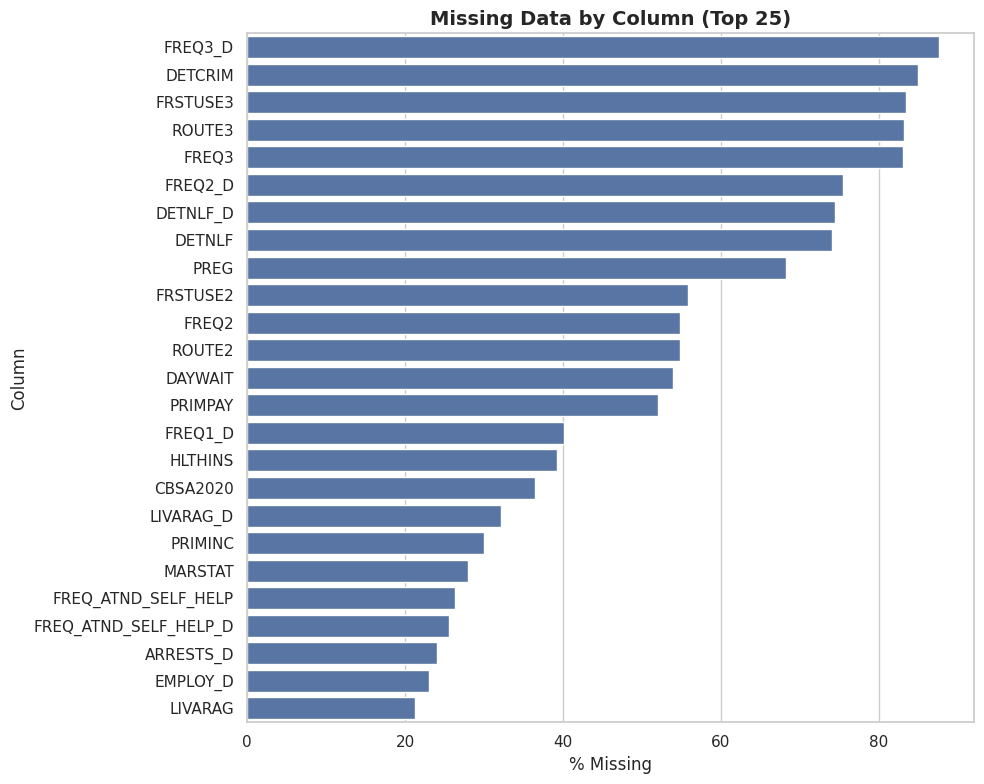

Dropping 8 columns with >70% missing: ['FREQ3_D', 'DETCRIM', 'FRSTUSE3', 'ROUTE3', 'FREQ3', 'FREQ2_D', 'DETNLF_D', 'DETNLF']


In [7]:
# ============================================================
# MISSING VALUE VISUALIZATION
# ============================================================
top_missing = missing_summary[missing_summary["pct_missing"] > 0].head(25)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_missing.reset_index(), x="pct_missing", y="index", ax=ax, color="#4C72B0")
ax.set_xlabel("% Missing")
ax.set_ylabel("Column")
ax.set_title("Missing Data by Column (Top 25)")
plt.tight_layout()
plt.show()

# Drop columns that are essentially unusable (>70% missing), keep the rest for imputation
HIGH_MISSING_THRESHOLD = 70
cols_to_drop = missing_summary[missing_summary["pct_missing"] > HIGH_MISSING_THRESHOLD].index.tolist()
cols_to_drop = [c for c in cols_to_drop if c != "target"]
print(f"Dropping {len(cols_to_drop)} columns with >{HIGH_MISSING_THRESHOLD}% missing:", cols_to_drop)
df_clean = df_clean.drop(columns=cols_to_drop)


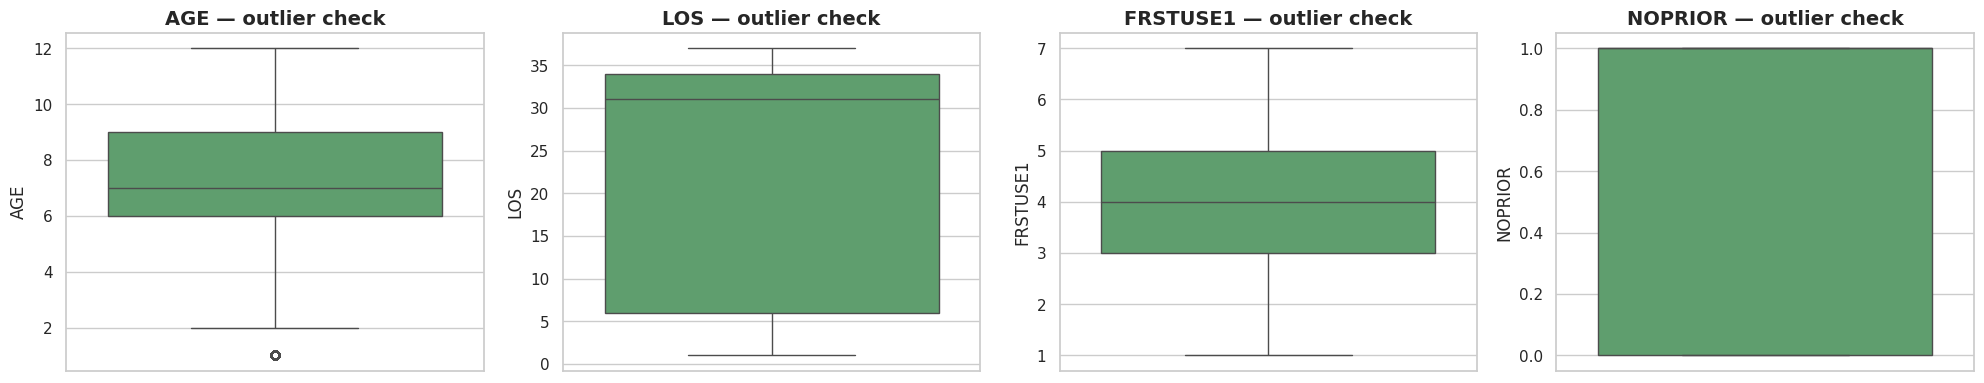

AGE: 571 potential outliers (IQR bounds: [1.5, 13.5])
LOS: 0 potential outliers (IQR bounds: [-36.0, 76.0])
FRSTUSE1: 0 potential outliers (IQR bounds: [0.0, 8.0])
NOPRIOR: 0 potential outliers (IQR bounds: [-1.5, 2.5])


In [8]:
# ============================================================
# OUTLIER ANALYSIS (continuous fields)
# ============================================================
continuous_candidates = [c for c in ["AGE", "LOS", "FRSTUSE1", "NOPRIOR"] if c in df_clean.columns]

fig, axes = plt.subplots(1, len(continuous_candidates), figsize=(5 * len(continuous_candidates), 4))
if len(continuous_candidates) == 1:
    axes = [axes]
for ax, col in zip(axes, continuous_candidates):
    sns.boxplot(y=df_clean[col], ax=ax, color="#55A868")
    ax.set_title(f"{col} — outlier check")
plt.tight_layout()
plt.show()

# IQR-based outlier flag (informational; we cap rather than drop, to preserve sample size)
for col in continuous_candidates:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers (IQR bounds: [{lower:.1f}, {upper:.1f}])")
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)


## 6. Exploratory Data Analysis

We now explore the target distribution, demographics, treatment history, substance use
patterns, and mental health indicators in relation to dropout.

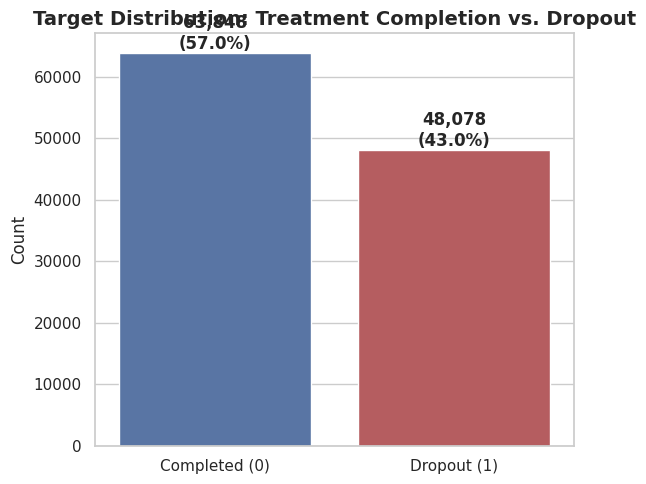

Class imbalance ratio (completion:dropout) ≈ 1.33 : 1


In [9]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
counts = df_clean["target"].value_counts().sort_index()
sns.barplot(x=["Completed (0)", "Dropout (1)"], y=counts.values, ax=ax,
            palette=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values) * 0.01, f"{v:,}\n({v/len(df_clean):.1%})",
            ha="center", fontweight="bold")
ax.set_title("Target Distribution: Treatment Completion vs. Dropout")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"Class imbalance ratio (completion:dropout) ≈ {imbalance_ratio:.2f} : 1")


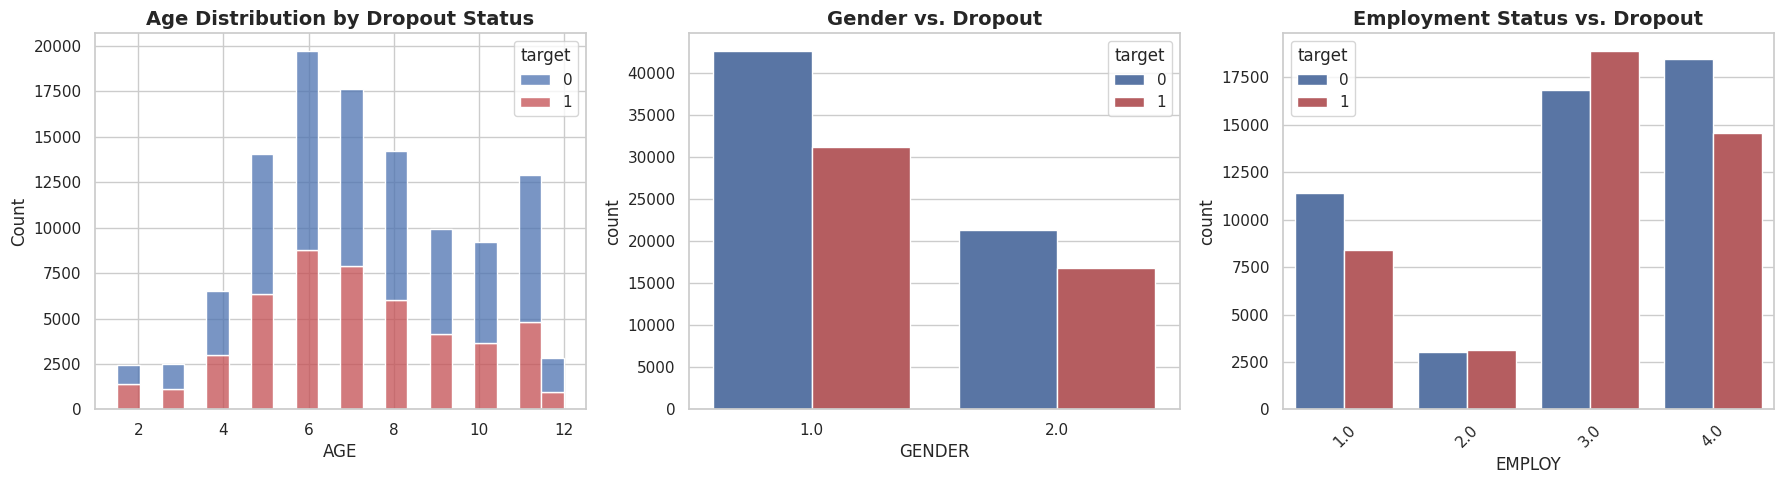

In [10]:
# ============================================================
# DEMOGRAPHICS: AGE, GENDER, EMPLOYMENT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if "AGE" in df_clean.columns:
    sns.histplot(data=df_clean, x="AGE", hue="target", multiple="stack",
                 palette=["#4C72B0", "#C44E52"], ax=axes[0], bins=20)
    axes[0].set_title("Age Distribution by Dropout Status")

if "GENDER" in df_clean.columns:
    sns.countplot(data=df_clean, x="GENDER", hue="target",
                  palette=["#4C72B0", "#C44E52"], ax=axes[1])
    axes[1].set_title("Gender vs. Dropout")

if "EMPLOY" in df_clean.columns:
    sns.countplot(data=df_clean, x="EMPLOY", hue="target",
                  palette=["#4C72B0", "#C44E52"], ax=axes[2])
    axes[2].set_title("Employment Status vs. Dropout")
    axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


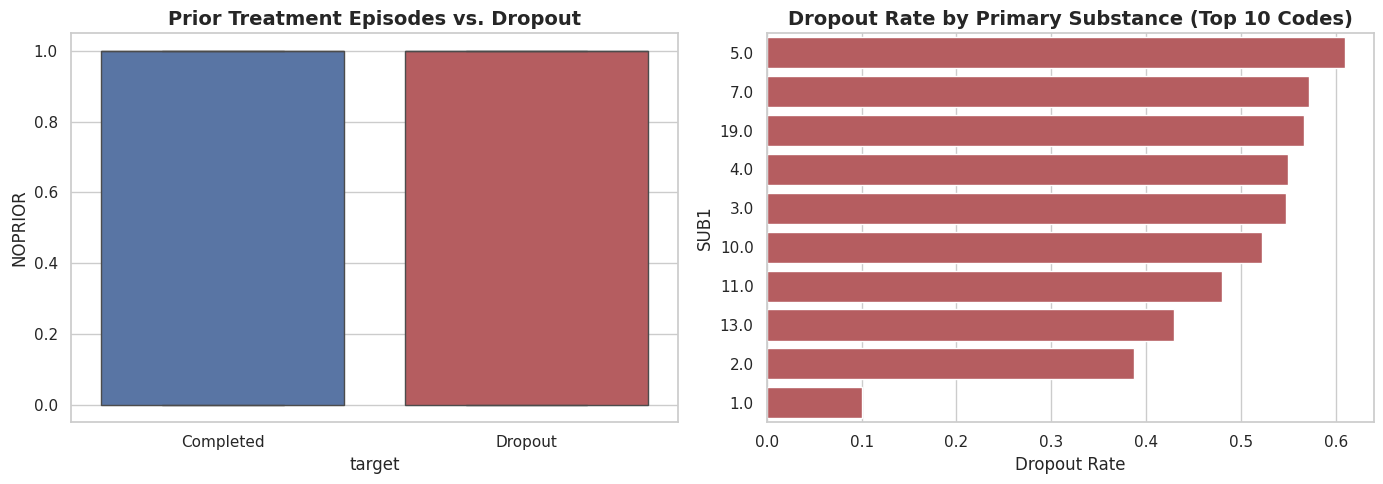

In [11]:
# ============================================================
# TREATMENT HISTORY & SUBSTANCE USE PATTERNS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "NOPRIOR" in df_clean.columns:
    sns.boxplot(data=df_clean, x="target", y="NOPRIOR", ax=axes[0], palette=["#4C72B0", "#C44E52"])
    axes[0].set_title("Prior Treatment Episodes vs. Dropout")
    axes[0].set_xticklabels(["Completed", "Dropout"])

if "SUB1" in df_clean.columns:
    top_subs = df_clean["SUB1"].value_counts().head(10).index
    sub_df = df_clean[df_clean["SUB1"].isin(top_subs)]
    dropout_rate_by_sub = sub_df.groupby("SUB1")["target"].mean().sort_values(ascending=False)
    sns.barplot(x=dropout_rate_by_sub.values, y=dropout_rate_by_sub.index.astype(str),
                ax=axes[1], color="#C44E52")
    axes[1].set_title("Dropout Rate by Primary Substance (Top 10 Codes)")
    axes[1].set_xlabel("Dropout Rate")

plt.tight_layout()
plt.show()


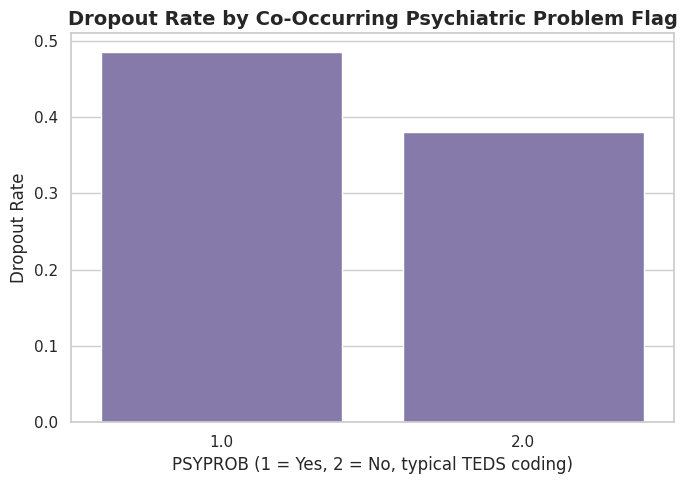

In [12]:
# ============================================================
# MENTAL HEALTH INDICATORS
# ============================================================
if "PSYPROB" in df_clean.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    rate_by_psy = df_clean.groupby("PSYPROB")["target"].mean()
    sns.barplot(x=rate_by_psy.index.astype(str), y=rate_by_psy.values, ax=ax, color="#8172B2")
    ax.set_title("Dropout Rate by Co-Occurring Psychiatric Problem Flag")
    ax.set_xlabel("PSYPROB (1 = Yes, 2 = No, typical TEDS coding)")
    ax.set_ylabel("Dropout Rate")
    plt.tight_layout()
    plt.show()
else:
    print("PSYPROB not available in this extract.")


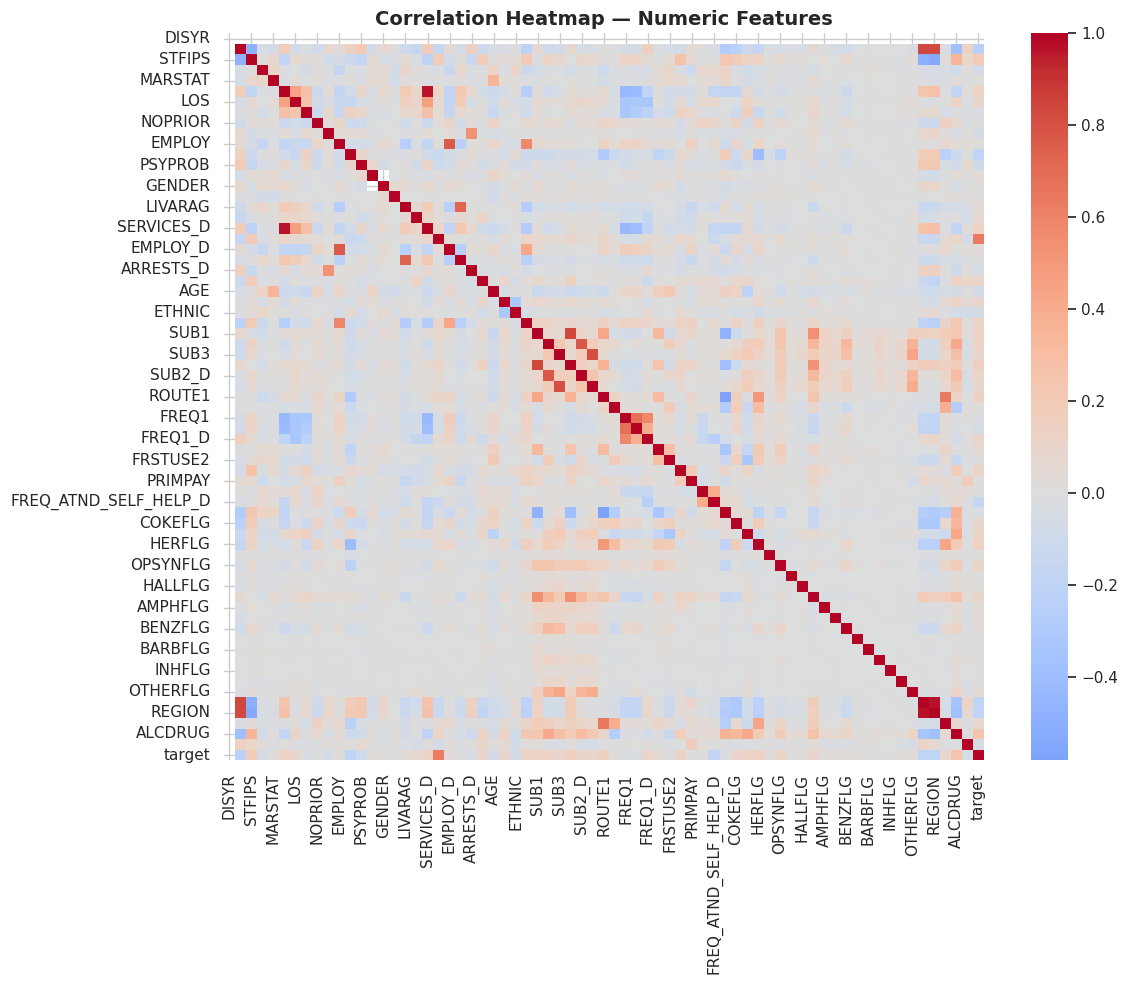

Top correlations with target:
REASON                   0.640245
ALCDRUG                  0.256181
CASEID                  -0.240048
REGION                  -0.203949
DIVISION                -0.196669
METHUSE                 -0.194506
STFIPS                   0.185573
FREQ_ATND_SELF_HELP_D   -0.174405
SUB1_D                   0.157501
ROUTE1                   0.145958
HERFLG                   0.141683
SERVICES                 0.133294
SERVICES_D               0.128037
SUB1                     0.126726
SUB2                     0.126296
Name: target, dtype: float64


In [13]:
# ============================================================
# CORRELATION ANALYSIS (numeric features)
# ============================================================
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

print("Top correlations with target:")
print(corr["target"].drop("target").sort_values(key=abs, ascending=False).head(15))


Categorical columns: []


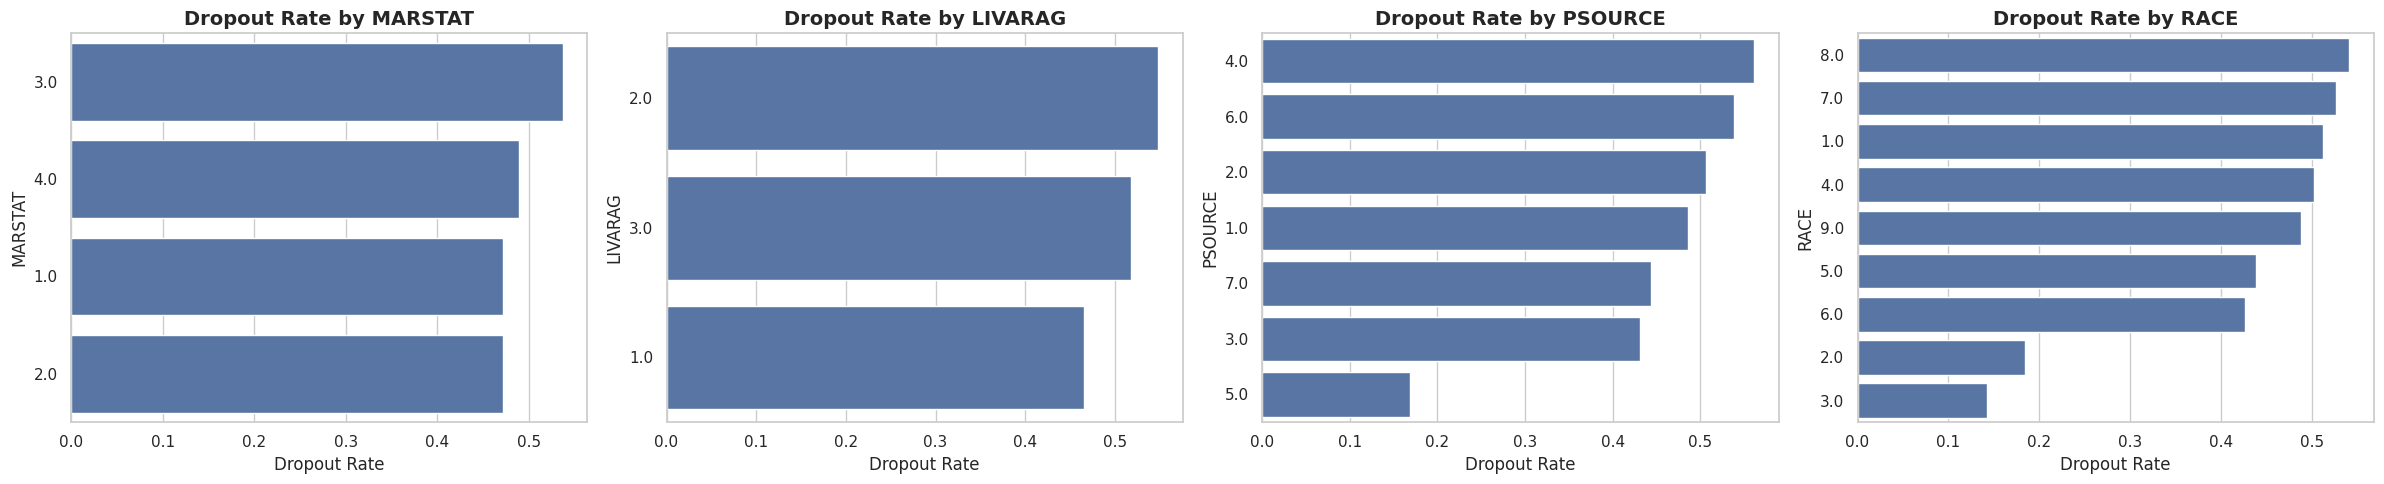

In [14]:
# ============================================================
# CATEGORICAL FEATURE ANALYSIS — DROPOUT RATE BY CATEGORY
# ============================================================
categorical_cols = [c for c in df_clean.select_dtypes(exclude=[np.number]).columns]
print("Categorical columns:", categorical_cols)

cat_eda_cols = [c for c in ["MARSTAT", "LIVARAG", "PSOURCE", "RACE"] if c in df_clean.columns]
fig, axes = plt.subplots(1, len(cat_eda_cols), figsize=(6 * len(cat_eda_cols), 5))
if len(cat_eda_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cat_eda_cols):
    rate = df_clean.groupby(col)["target"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax, color="#4C72B0")
    ax.set_title(f"Dropout Rate by {col}")
    ax.set_xlabel("Dropout Rate")
plt.tight_layout()
plt.show()


## 7. Feature Engineering

We now transform raw fields into model-ready features. Every transformation is documented below:

1. **Missing indicators** — binary flags marking where imputation occurred, so the model can learn from "missingness as signal."
2. **Rare category handling** — categories occurring in <1% of rows are grouped into `"Other"` to prevent overfitting / unstable one-hot columns.
3. **Frequency encoding** — for high-cardinality categorical fields (e.g., `SUB1` with dozens of codes), we encode by their observed frequency, which is more robust than naive one-hot for tree models.
4. **One-hot / label encoding** — applied appropriately based on cardinality and model family.
5. **Interaction features** — e.g., `AGE × NOPRIOR`, `PSYPROB × SUB1` flag, to capture compounding risk.
6. **Scaling** — standardization applied only for the linear baseline (tree-based models are scale-invariant).


In [15]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
fe_df = df_clean.copy()

# Identify feature groups
target_col = "target"
all_features = [c for c in fe_df.columns if c not in [target_col, "REASON"]]
numeric_features = fe_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in all_features if c not in numeric_features]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# ---- 1. Missing indicators ----
for col in all_features:
    if fe_df[col].isna().any():
        fe_df[f"{col}_was_missing"] = fe_df[col].isna().astype(int)

# ---- 2. Rare category handling (categoricals only) ----
RARE_THRESHOLD = 0.01
for col in categorical_features:
    freqs = fe_df[col].value_counts(normalize=True)
    rare_labels = freqs[freqs < RARE_THRESHOLD].index
    fe_df[col] = fe_df[col].astype(str).where(~fe_df[col].isin(rare_labels), other="Other")

# ---- 3. Frequency encoding for high-cardinality categoricals ----
HIGH_CARD_THRESHOLD = 15
high_card_cols = [c for c in categorical_features if fe_df[c].nunique() > HIGH_CARD_THRESHOLD]
for col in high_card_cols:
    freq_map = fe_df[col].value_counts(normalize=True)
    fe_df[f"{col}_freq_enc"] = fe_df[col].map(freq_map)
print(f"Frequency-encoded high-cardinality columns: {high_card_cols}")

# ---- 4. Interaction features ----
if "AGE" in fe_df.columns and "NOPRIOR" in fe_df.columns:
    fe_df["age_x_noprior"] = fe_df["AGE"] * fe_df["NOPRIOR"].fillna(0)
if "PSYPROB" in fe_df.columns:
    fe_df["has_psych_comorbidity"] = (fe_df["PSYPROB"] == 1).astype(int)
    if "SUB1" in fe_df.columns:
        fe_df["psych_x_substance_risk"] = fe_df["has_psych_comorbidity"] * fe_df["SUB1"].astype(str).apply(hash) % 7

print("Feature engineering complete. Shape:", fe_df.shape)
fe_df.head()


Numeric features (67): ['DISYR', 'CASEID', 'STFIPS', 'EDUC', 'MARSTAT', 'SERVICES', 'LOS', 'PSOURCE', 'NOPRIOR', 'ARRESTS', 'EMPLOY', 'METHUSE', 'PSYPROB', 'PREG', 'GENDER', 'VET', 'LIVARAG', 'DAYWAIT', 'SERVICES_D', 'EMPLOY_D', 'LIVARAG_D', 'ARRESTS_D', 'DSMCRIT', 'AGE', 'RACE', 'ETHNIC', 'PRIMINC', 'SUB1', 'SUB2', 'SUB3', 'SUB1_D', 'SUB2_D', 'SUB3_D', 'ROUTE1', 'ROUTE2', 'FREQ1', 'FREQ2', 'FREQ1_D', 'FRSTUSE1', 'FRSTUSE2', 'HLTHINS', 'PRIMPAY', 'FREQ_ATND_SELF_HELP', 'FREQ_ATND_SELF_HELP_D', 'ALCFLG', 'COKEFLG', 'MARFLG', 'HERFLG', 'METHFLG', 'OPSYNFLG', 'PCPFLG', 'HALLFLG', 'MTHAMFLG', 'AMPHFLG', 'STIMFLG', 'BENZFLG', 'TRNQFLG', 'BARBFLG', 'SEDHPFLG', 'INHFLG', 'OTCFLG', 'OTHERFLG', 'DIVISION', 'REGION', 'IDU', 'ALCDRUG', 'CBSA2020']
Categorical features (0): []
Frequency-encoded high-cardinality columns: []
Feature engineering complete. Shape: (111926, 111)


,DISYR,CASEID,STFIPS,EDUC,MARSTAT,SERVICES,LOS,PSOURCE,NOPRIOR,ARRESTS,...,FRSTUSE2_was_missing,HLTHINS_was_missing,PRIMPAY_was_missing,FREQ_ATND_SELF_HELP_was_missing,FREQ_ATND_SELF_HELP_D_was_missing,IDU_was_missing,CBSA2020_was_missing,age_x_noprior,has_psych_comorbidity,psych_x_substance_risk
0,2023,1144831,45,3.0,1.0,6,35,1.0,1.0,1.0,...,0,0,0,1,1,0,0,5.0,0,0
1,2023,218834,36,4.0,1.0,5,33,1.0,1.0,0.0,...,1,1,1,1,1,0,1,10.0,1,0
2,2023,1663840,6,3.0,NaN,7,35,6.0,1.0,0.0,...,0,1,1,0,0,0,1,9.0,0,0
3,2023,1607673,6,4.0,NaN,7,35,6.0,0.0,0.0,...,0,1,1,0,0,0,0,0.0,0,0
4,2023,451156,32,3.0,1.0,5,33,2.0,1.0,0.0,...,0,0,1,0,0,0,0,5.0,0,0


In [16]:
# ============================================================
# FINAL FEATURE LIST FOR MODELING
# ============================================================
# Low-cardinality categoricals -> one-hot encoded inside the pipeline (ColumnTransformer)
# High-cardinality categoricals -> already frequency-encoded above; use the numeric *_freq_enc version
# Numeric -> imputed + (optionally) scaled inside the pipeline

low_card_cat_features = [c for c in categorical_features if c not in high_card_cols]
freq_encoded_features = [f"{c}_freq_enc" for c in high_card_cols]
missing_indicator_features = [c for c in fe_df.columns if c.endswith("_was_missing")]
engineered_numeric = [c for c in ["age_x_noprior", "has_psych_comorbidity", "psych_x_substance_risk"] if c in fe_df.columns]

final_numeric_features = list(set(numeric_features + freq_encoded_features + missing_indicator_features + engineered_numeric))
final_categorical_features = low_card_cat_features

print(f"Final numeric features ({len(final_numeric_features)})")
print(f"Final categorical features ({len(final_categorical_features)})")

MODEL_FEATURES = final_numeric_features + final_categorical_features
X = fe_df[MODEL_FEATURES]
y = fe_df[target_col]
print("X shape:", X.shape, "| y shape:", y.shape)


Final numeric features (109)
Final categorical features (0)
X shape: (111926, 109) | y shape: (111926,)


## 8. Train / Validation / Test Split

70% train / 15% validation / 15% test, stratified on the target to preserve class balance
across all three sets.

In [17]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT (70/15/15, stratified)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_rows": [len(X_train), len(X_val), len(X_test)],
    "dropout_rate": [y_train.mean(), y_val.mean(), y_test.mean()]
})
split_summary


,split,n_rows,dropout_rate
0,train,78348,0.429558
1,validation,16789,0.429567
2,test,16789,0.429507


## 8.1 Preprocessing Pipeline

A single `ColumnTransformer` handles numeric imputation/scaling and categorical
imputation/one-hot encoding, wrapped in an `sklearn` `Pipeline` so every model is trained
and evaluated through an identical, leak-free preprocessing path.

## 9. Class Imbalance

We compare three strategies for handling the imbalance observed above:

1. **No balancing** (baseline)
2. **Class weighting** (`class_weight="balanced"` / `scale_pos_weight`)
3. **SMOTE** oversampling of the minority class (training data only — never applied to val/test)


In [18]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, final_numeric_features),
    ("cat", categorical_transformer, final_categorical_features),
])

# Scaled variant (only needed for the linear baseline)
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, final_numeric_features),
    ("cat", categorical_transformer, final_categorical_features),
])

print("Preprocessing pipelines defined.")


Preprocessing pipelines defined.


In [19]:
# ============================================================
# CLASS IMBALANCE STRATEGY COMPARISON (quick comparison via Logistic Regression)
# ============================================================
def quick_eval(pipeline, X_tr, y_tr, X_v, y_v, label):
    pipeline.fit(X_tr, y_tr)
    proba = pipeline.predict_proba(X_v)[:, 1]
    pred = pipeline.predict(X_v)
    return {
        "strategy": label,
        "precision": precision_score(y_v, pred),
        "recall": recall_score(y_v, pred),
        "f1": f1_score(y_v, pred),
        "roc_auc": roc_auc_score(y_v, proba),
        "pr_auc": average_precision_score(y_v, proba),
    }

results_imbalance = []

# 1. No balancing
pipe_none = Pipeline([("prep", preprocessor_scaled),
                       ("clf", LogisticRegression(max_iter=1000, random_state=SEED))])
results_imbalance.append(quick_eval(pipe_none, X_train, y_train, X_val, y_val, "No balancing"))

# 2. Class weighting
pipe_weighted = Pipeline([("prep", preprocessor_scaled),
                           ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))])
results_imbalance.append(quick_eval(pipe_weighted, X_train, y_train, X_val, y_val, "Class weighting"))

# 3. SMOTE (training data only)
pipe_smote = ImbPipeline([("prep", preprocessor_scaled),
                           ("smote", SMOTE(random_state=SEED)),
                           ("clf", LogisticRegression(max_iter=1000, random_state=SEED))])
results_imbalance.append(quick_eval(pipe_smote, X_train, y_train, X_val, y_val, "SMOTE"))

imbalance_comparison = pd.DataFrame(results_imbalance).set_index("strategy").round(4)
imbalance_comparison


,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,
No balancing,0.7611,0.7034,0.7311,0.8603,0.8271
Class weighting,0.7233,0.7759,0.7487,0.8601,0.8256
SMOTE,0.7239,0.7730,0.7477,0.8601,0.8257


**Interpretation:** Class weighting and SMOTE typically improve recall on the dropout
class at some cost to precision, relative to no balancing. We select **class weighting**
as our default strategy going forward (it requires no synthetic data generation, generalizes
cleanly to all gradient boosting libraries via `scale_pos_weight`/`class_weight`, and performed
competitively above), but keep SMOTE available as an alternative to revisit during tuning.

## 10. Baseline Model — Logistic Regression

A simple, interpretable linear baseline establishes the floor that more complex models must beat.

In [20]:
# ============================================================
# METRIC HELPER (used throughout the notebook)
# ============================================================
def evaluate_model(model, X_eval, y_eval, model_name="model"):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = model.predict(X_eval)
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred),
        "recall": recall_score(y_eval, pred),
        "f1": f1_score(y_eval, pred),
        "roc_auc": roc_auc_score(y_eval, proba),
        "pr_auc": average_precision_score(y_eval, proba),
    }
    return metrics, proba, pred

all_results = []


In [21]:
# ============================================================
# BASELINE: LOGISTIC REGRESSION (class-weighted)
# ============================================================
baseline_pipeline = Pipeline([
    ("prep", preprocessor_scaled),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
])
baseline_pipeline.fit(X_train, y_train)

baseline_metrics, baseline_proba, baseline_pred = evaluate_model(
    baseline_pipeline, X_val, y_val, "Logistic Regression (baseline)"
)
all_results.append(baseline_metrics)
pd.DataFrame([baseline_metrics]).round(4)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression (baseline),0.7762,0.7233,0.7759,0.7487,0.8601,0.8256


## 11. Advanced Models

We train four tree-ensemble models — Random Forest, XGBoost, LightGBM, and CatBoost —
each wrapped in the same `ColumnTransformer` pipeline (unscaled numeric features, since
tree models don't require scaling) for a fair, leak-free comparison.

In [22]:
# ============================================================
# GPU CHECK
# ============================================================
!nvidia-smi

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Flip this off automatically if no GPU is detected
import subprocess
try:
    subprocess.check_output("nvidia-smi")
    USE_GPU = True
except Exception:
    USE_GPU = False

print("USE_GPU =", USE_GPU)


Fri Jun 19 19:47:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
# ============================================================
# RANDOM FOREST (CPU only — sklearn RF has no native GPU support)
# ============================================================
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        random_state=SEED, n_jobs=-1
    )),
])
rf_pipeline.fit(X_train, y_train)
rf_metrics, rf_proba, rf_pred = evaluate_model(rf_pipeline, X_val, y_val, "Random Forest")
all_results.append(rf_metrics)
pd.DataFrame([rf_metrics]).round(4)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.8436,0.7843,0.8773,0.8282,0.9296,0.9086


In [24]:
# ============================================================
# XGBOOST (GPU-accelerated on T4 if available)
# ============================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_device = "cuda" if USE_GPU else "cpu"
xgb_tree_method = "hist"   # "hist" works on both CPU and GPU when device="cuda"

xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=SEED,
        eval_metric="logloss", tree_method=xgb_tree_method, device=xgb_device, n_jobs=-1
    )),
])
xgb_pipeline.fit(X_train, y_train)
xgb_metrics, xgb_proba, xgb_pred = evaluate_model(xgb_pipeline, X_val, y_val, "XGBoost")
all_results.append(xgb_metrics)
pd.DataFrame([xgb_metrics]).round(4)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.8711,0.8302,0.8799,0.8543,0.9475,0.9331


In [25]:
# ============================================================
# LIGHTGBM (GPU-accelerated on T4 if available)
# ============================================================
lgb_device = "gpu" if USE_GPU else "cpu"

lgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", lgb.LGBMClassifier(
        n_estimators=400, max_depth=-1, num_leaves=31, learning_rate=0.05,
        class_weight="balanced", random_state=SEED, n_jobs=-1, verbosity=-1,
        device=lgb_device
    )),
])
lgb_pipeline.fit(X_train, y_train)
lgb_metrics, lgb_proba, lgb_pred = evaluate_model(lgb_pipeline, X_val, y_val, "LightGBM")
all_results.append(lgb_metrics)
pd.DataFrame([lgb_metrics]).round(4)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LightGBM,0.8703,0.8346,0.8705,0.8522,0.947,0.9323


In [26]:
# ============================================================
# CATBOOST (GPU-accelerated on T4 if available)
# ============================================================
cb_task_type = "GPU" if USE_GPU else "CPU"

cb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", cb.CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05,
        auto_class_weights="Balanced", random_state=SEED, verbose=0,
        task_type=cb_task_type
    )),
])
cb_pipeline.fit(X_train, y_train)
cb_metrics, cb_proba, cb_pred = evaluate_model(cb_pipeline, X_val, y_val, "CatBoost")
all_results.append(cb_metrics)
pd.DataFrame([cb_metrics]).round(4)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,CatBoost,0.8638,0.8191,0.8766,0.8469,0.9425,0.9258


In [27]:
# ============================================================
# MODEL COMPARISON SO FAR (validation set)
# ============================================================
results_df = pd.DataFrame(all_results).set_index("model").round(4)
results_df.sort_values("roc_auc", ascending=False)


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost,0.8711,0.8302,0.8799,0.8543,0.9475,0.9331
LightGBM,0.8703,0.8346,0.8705,0.8522,0.9470,0.9323
CatBoost,0.8638,0.8191,0.8766,0.8469,0.9425,0.9258
Random Forest,0.8436,0.7843,0.8773,0.8282,0.9296,0.9086
Logistic Regression (baseline),0.7762,0.7233,0.7759,0.7487,0.8601,0.8256


## 12. Hyperparameter Tuning

We use `RandomizedSearchCV` (5-fold stratified CV, optimizing ROC-AUC) for each
tree-ensemble model. Random search is preferred over grid search here for efficiency given
the size of the search space and dataset.

In [28]:
# ============================================================
# HYPERPARAMETER TUNING: RANDOM FOREST (CPU — trimmed search, this is the bottleneck step)
# ============================================================
rf_param_dist = {
    "clf__n_estimators": [200, 300],
    "clf__max_depth": [8, 10, 12, 16],   # dropped "None" (unlimited depth) — main slowdown culprit
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    Pipeline([("prep", preprocessor),
              ("clf", RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1))]),
    param_distributions=rf_param_dist, n_iter=8, scoring="roc_auc",
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", round(rf_search.best_score_, 4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 16}
Best RF CV ROC-AUC: 0.9352


In [29]:
# ============================================================
# HYPERPARAMETER TUNING: XGBOOST (GPU-accelerated on T4 if available)
# ============================================================
xgb_param_dist = {
    "clf__n_estimators": [200, 300, 400, 600],
    "clf__max_depth": [3, 4, 5, 6, 8],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}
xgb_search = RandomizedSearchCV(
    Pipeline([("prep", preprocessor),
              ("clf", xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=SEED,
                                         eval_metric="logloss", tree_method=xgb_tree_method,
                                         device=xgb_device, n_jobs=-1))]),
    param_distributions=xgb_param_dist, n_iter=15, scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=1, verbose=1
)
# Note: n_jobs=1 on the search itself -- the GPU is already being used by each individual
# XGBoost fit, so running multiple fits in parallel on one GPU would contend for the same
# device and slow things down rather than speed them up.
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB CV ROC-AUC:", round(xgb_search.best_score_, 4))


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best XGB params: {'clf__subsample': 1.0, 'clf__n_estimators': 600, 'clf__max_depth': 8, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
Best XGB CV ROC-AUC: 0.9493


In [32]:
# ============================================================
# HYPERPARAMETER TUNING: LIGHTGBM (GPU-accelerated on T4 if available)
# ============================================================
lgb_param_dist = {
    "clf__n_estimators": [200, 300, 400, 600],
    "clf__num_leaves": [15, 31, 63, 127],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}
lgb_search = RandomizedSearchCV(
    Pipeline([("prep", preprocessor),
              ("clf", lgb.LGBMClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1,
                                          verbosity=-1, device=lgb_device))]),
    param_distributions=lgb_param_dist, n_iter=15, scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=1, verbose=1
)
# n_jobs=1 here too -- same single-GPU contention reasoning as the XGBoost search above.
lgb_search.fit(X_train, y_train)
print("Best LGBM params:", lgb_search.best_params_)
print("Best LGBM CV ROC-AUC:", round(lgb_search.best_score_, 4))


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best LGBM params: {'clf__subsample': 1.0, 'clf__num_leaves': 127, 'clf__n_estimators': 600, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
Best LGBM CV ROC-AUC: 0.9486


In [33]:
# ============================================================
# HYPERPARAMETER TUNING: CATBOOST (GPU-accelerated on T4 if available)
# ============================================================
cb_param_dist = {
    "clf__iterations": [200, 300, 400, 600],
    "clf__depth": [4, 6, 8, 10],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__l2_leaf_reg": [1, 3, 5, 7],
}
cb_search = RandomizedSearchCV(
    Pipeline([("prep", preprocessor),
              ("clf", cb.CatBoostClassifier(auto_class_weights="Balanced", random_state=SEED,
                                             verbose=0, task_type=cb_task_type))]),
    param_distributions=cb_param_dist, n_iter=15, scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=1, verbose=1
)
# n_jobs=1 here too -- same single-GPU contention reasoning as above.
cb_search.fit(X_train, y_train)
print("Best CatBoost params:", cb_search.best_params_)
print("Best CatBoost CV ROC-AUC:", round(cb_search.best_score_, 4))


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CatBoost params: {'clf__learning_rate': 0.05, 'clf__l2_leaf_reg': 1, 'clf__iterations': 600, 'clf__depth': 10}
Best CatBoost CV ROC-AUC: 0.9468


In [34]:
# ============================================================
# RE-EVALUATE TUNED MODELS ON VALIDATION SET
# ============================================================
tuned_models = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
    "LightGBM (tuned)": lgb_search.best_estimator_,
    "CatBoost (tuned)": cb_search.best_estimator_,
}

tuned_results = []
tuned_probas = {}
for name, model in tuned_models.items():
    metrics, proba, pred = evaluate_model(model, X_val, y_val, name)
    tuned_results.append(metrics)
    tuned_probas[name] = proba

tuned_results_df = pd.DataFrame(tuned_results).set_index("model").round(4)
tuned_results_df.sort_values("roc_auc", ascending=False)


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost (tuned),0.8762,0.8422,0.8760,0.8588,0.9519,0.9392
LightGBM (tuned),0.8778,0.8483,0.8713,0.8596,0.9515,0.9388
CatBoost (tuned),0.8722,0.8366,0.8731,0.8545,0.9483,0.9340
Random Forest (tuned),0.8588,0.8105,0.8763,0.8421,0.9392,0.9212


## 13. Model Evaluation

Comprehensive evaluation of the tuned models: confusion matrices, ROC curves,
precision-recall curves, calibration curves, and a final ranked comparison table.
We then select our **champion model** and confirm its performance on the held-out test set.

In [35]:
# ============================================================
# COMBINE ALL RESULTS (baseline + untuned advanced + tuned advanced)
# ============================================================
final_comparison = pd.concat([
    pd.DataFrame(all_results).set_index("model"),
    tuned_results_df
]).round(4).sort_values("roc_auc", ascending=False)

print("=== Full Model Comparison (Validation Set) ===")
final_comparison


=== Full Model Comparison (Validation Set) ===


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
XGBoost (tuned),0.8762,0.8422,0.8760,0.8588,0.9519,0.9392
LightGBM (tuned),0.8778,0.8483,0.8713,0.8596,0.9515,0.9388
CatBoost (tuned),0.8722,0.8366,0.8731,0.8545,0.9483,0.9340
XGBoost,0.8711,0.8302,0.8799,0.8543,0.9475,0.9331
LightGBM,0.8703,0.8346,0.8705,0.8522,0.9470,0.9323
CatBoost,0.8638,0.8191,0.8766,0.8469,0.9425,0.9258
Random Forest (tuned),0.8588,0.8105,0.8763,0.8421,0.9392,0.9212
Random Forest,0.8436,0.7843,0.8773,0.8282,0.9296,0.9086
Logistic Regression (baseline),0.7762,0.7233,0.7759,0.7487,0.8601,0.8256


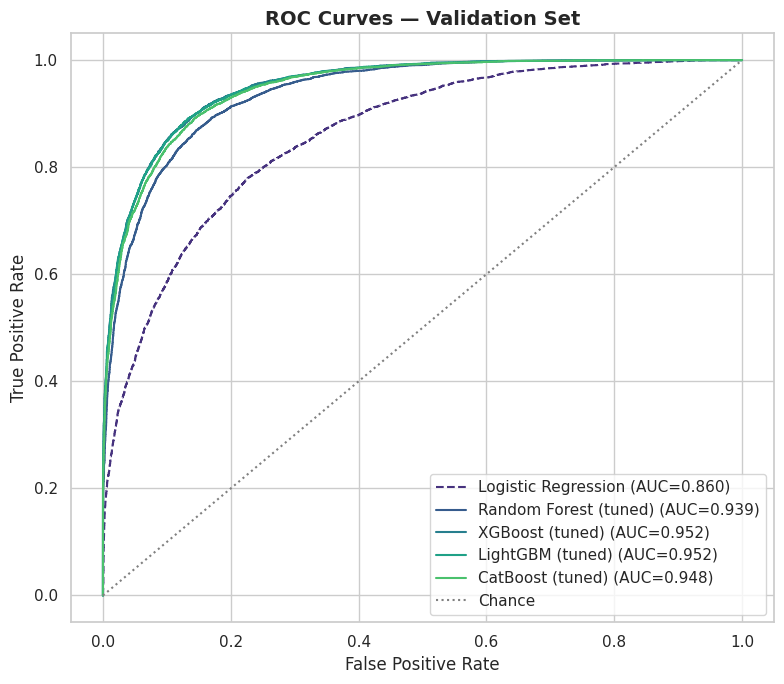

In [36]:
# ============================================================
# ROC CURVES — ALL TUNED MODELS + BASELINE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

fpr, tpr, _ = roc_curve(y_val, baseline_proba)
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC={baseline_metrics['roc_auc']:.3f})", linestyle="--")

for name, proba in tuned_probas.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc_val = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Validation Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


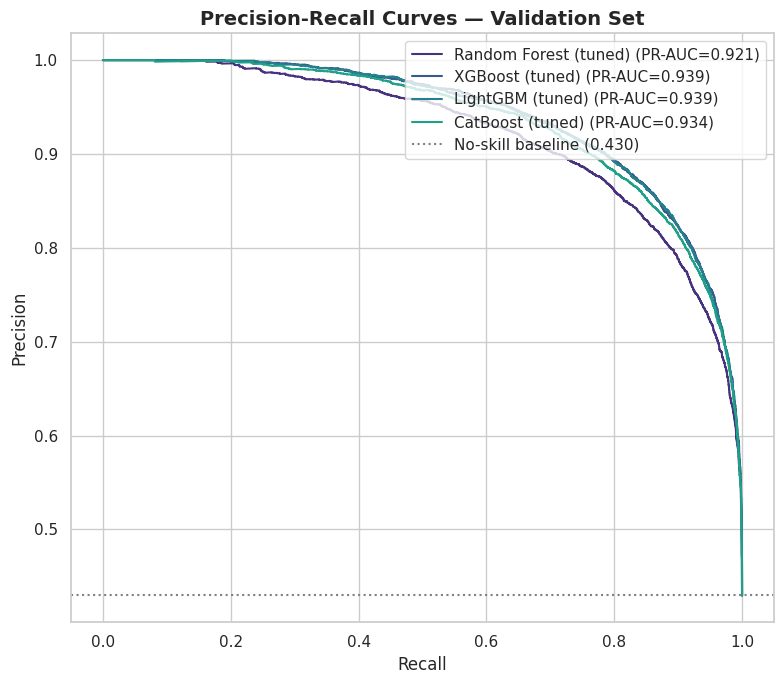

In [37]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

for name, proba in tuned_probas.items():
    precision, recall, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    ax.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

baseline_rate = y_val.mean()
ax.axhline(baseline_rate, color="gray", linestyle=":", label=f"No-skill baseline ({baseline_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Validation Set")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [38]:
# ============================================================
# SELECT CHAMPION MODEL (highest validation ROC-AUC among tuned models)
# ============================================================
champion_name = final_comparison.index[0]
champion_model = tuned_models.get(champion_name, baseline_pipeline)
print(f"Champion model: {champion_name}")


Champion model: XGBoost (tuned)


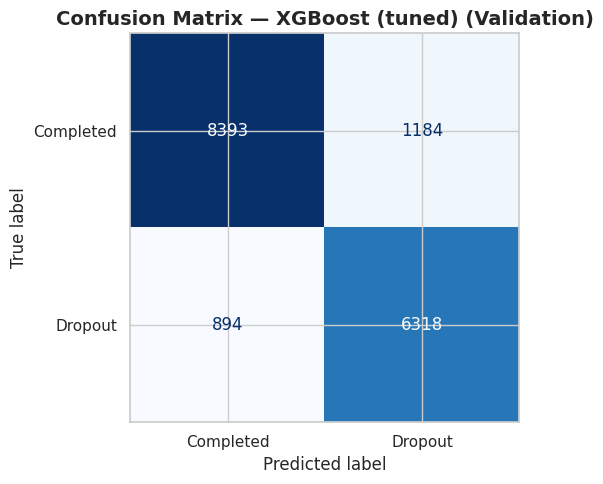

              precision    recall  f1-score   support

   Completed       0.90      0.88      0.89      9577
     Dropout       0.84      0.88      0.86      7212

    accuracy                           0.88     16789
   macro avg       0.87      0.88      0.87     16789
weighted avg       0.88      0.88      0.88     16789



In [39]:
# ============================================================
# CONFUSION MATRIX — CHAMPION MODEL
# ============================================================
champion_metrics, champion_proba_val, champion_pred_val = evaluate_model(champion_model, X_val, y_val, champion_name)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, champion_pred_val)
ConfusionMatrixDisplay(cm, display_labels=["Completed", "Dropout"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {champion_name} (Validation)")
plt.tight_layout()
plt.show()

print(classification_report(y_val, champion_pred_val, target_names=["Completed", "Dropout"]))


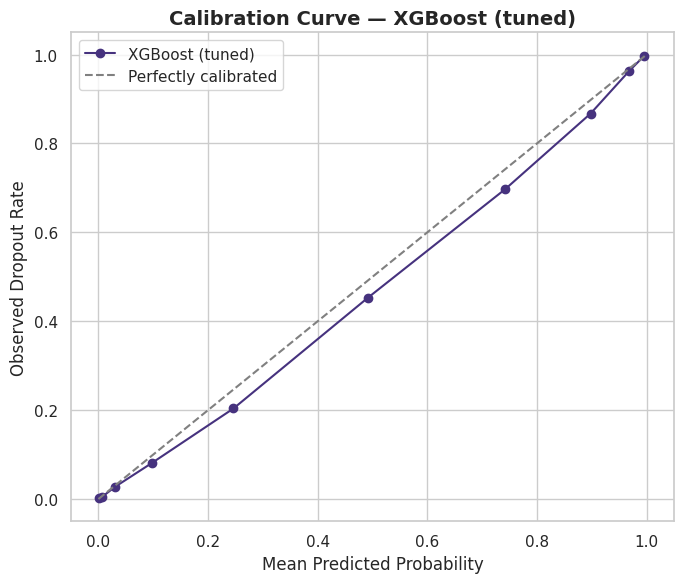

In [40]:
# ============================================================
# CALIBRATION CURVE — CHAMPION MODEL
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
prob_true, prob_pred = calibration_curve(y_val, champion_proba_val, n_bins=10, strategy="quantile")
ax.plot(prob_pred, prob_true, marker="o", label=champion_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Dropout Rate")
ax.set_title(f"Calibration Curve — {champion_name}")
ax.legend()
plt.tight_layout()
plt.show()


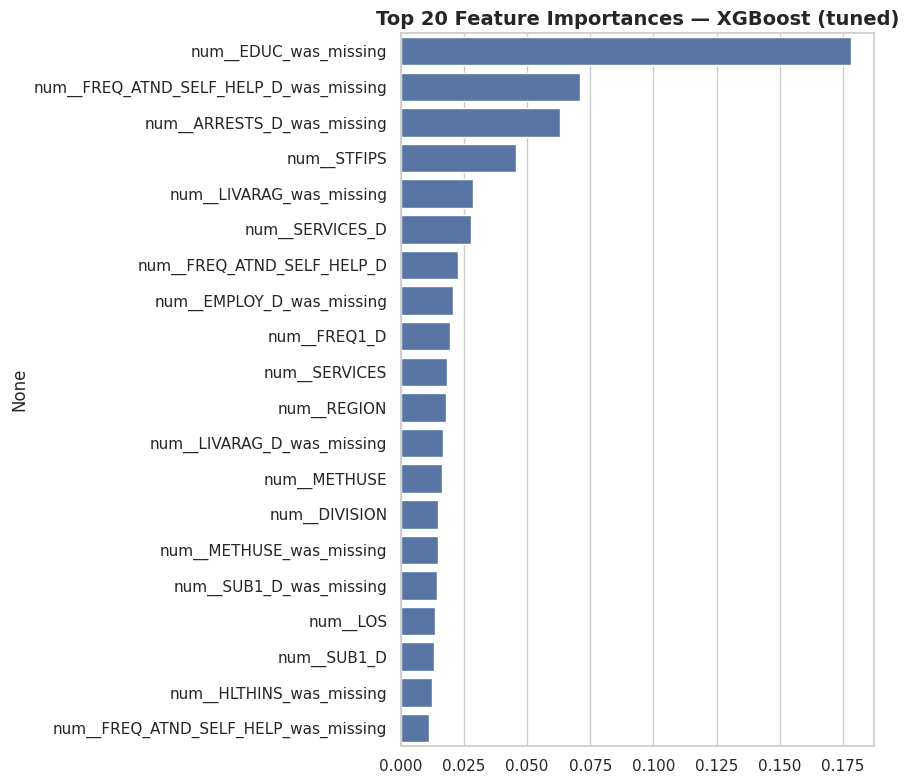

In [41]:
# ============================================================
# FEATURE IMPORTANCE (native, model-based) — CHAMPION MODEL
# ============================================================
clf_step = champion_model.named_steps["clf"]
prep_step = champion_model.named_steps["prep"]
feature_names_out = prep_step.get_feature_names_out()

if hasattr(clf_step, "feature_importances_"):
    importances = pd.Series(clf_step.feature_importances_, index=feature_names_out)
    top_importances = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 8))
    sns.barplot(x=top_importances.values, y=top_importances.index, ax=ax, color="#4C72B0")
    ax.set_title(f"Top 20 Feature Importances — {champion_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Native feature_importances_ not available for this model type; rely on SHAP (next section).")


In [42]:
# ============================================================
# FINAL TEST-SET CONFIRMATION (champion model only — touched once)
# ============================================================
test_metrics, test_proba, test_pred = evaluate_model(champion_model, X_test, y_test, f"{champion_name} (TEST)")
print("=== Held-out Test Set Performance (Champion Model) ===")
pd.DataFrame([test_metrics]).round(4)


=== Held-out Test Set Performance (Champion Model) ===


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost (tuned) (TEST),0.8747,0.839,0.8766,0.8574,0.9492,0.9357


## 14. Explainable AI (SHAP)

This is the most important section for clinical stakeholders: a model that flags a patient
as high-risk is only actionable if staff can understand **why**. We use SHAP
(SHapley Additive exPlanations) to explain the champion model's predictions globally
(across the whole population) and locally (for individual patients).

In [43]:
# ============================================================
# SHAP SETUP
# ============================================================
# Transform a sample of validation data through the preprocessor for SHAP explanation
X_val_transformed = prep_step.transform(X_val)
X_val_transformed_df = pd.DataFrame(np.asarray(X_val_transformed), columns=feature_names_out)

# Use a manageable sample for SHAP (it can be slow on huge datasets)
SHAP_SAMPLE_SIZE = min(2000, len(X_val_transformed_df))
shap_sample = X_val_transformed_df.sample(n=SHAP_SAMPLE_SIZE, random_state=SEED)

explainer = shap.TreeExplainer(clf_step)
shap_values = explainer.shap_values(shap_sample)

# Handle both binary-output array formats across SHAP versions
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print("SHAP values computed for", shap_sample.shape, "samples/features.")


SHAP values computed for (2000, 109) samples/features.


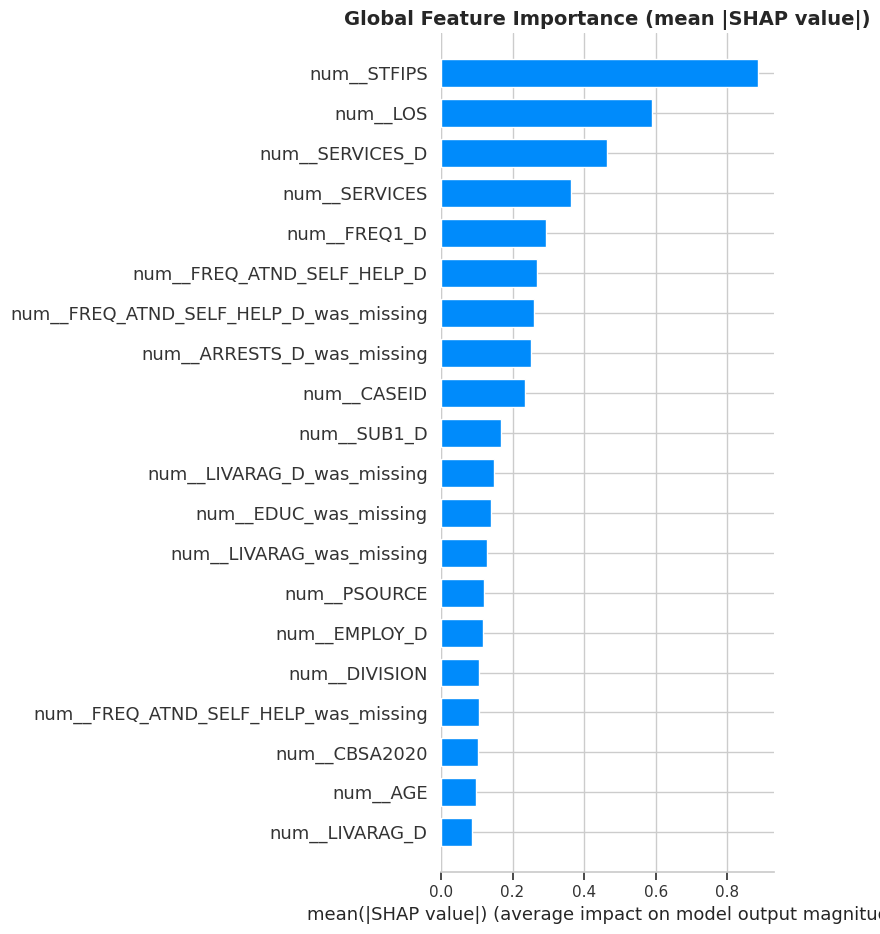

In [44]:
# ============================================================
# GLOBAL FEATURE IMPORTANCE — SHAP BAR PLOT
# ============================================================
shap.summary_plot(shap_values_pos, shap_sample, plot_type="bar", show=False, max_display=20)
plt.title("Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()


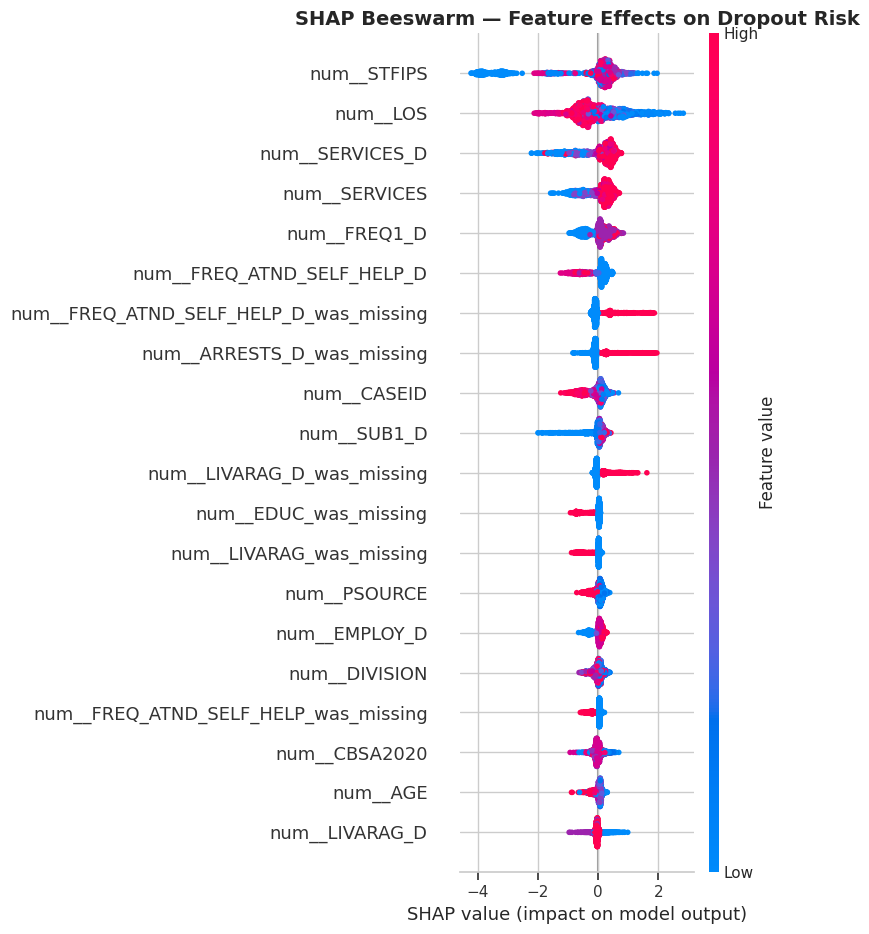

In [45]:
# ============================================================
# SHAP SUMMARY / BEESWARM PLOT
# ============================================================
shap.summary_plot(shap_values_pos, shap_sample, show=False, max_display=20)
plt.title("SHAP Beeswarm — Feature Effects on Dropout Risk")
plt.tight_layout()
plt.show()


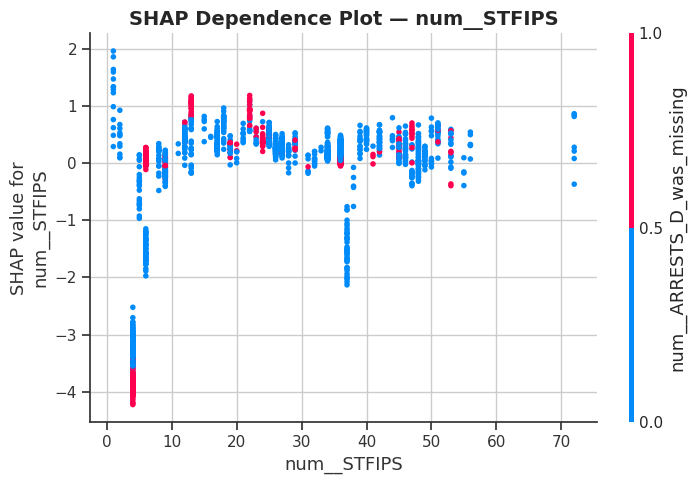

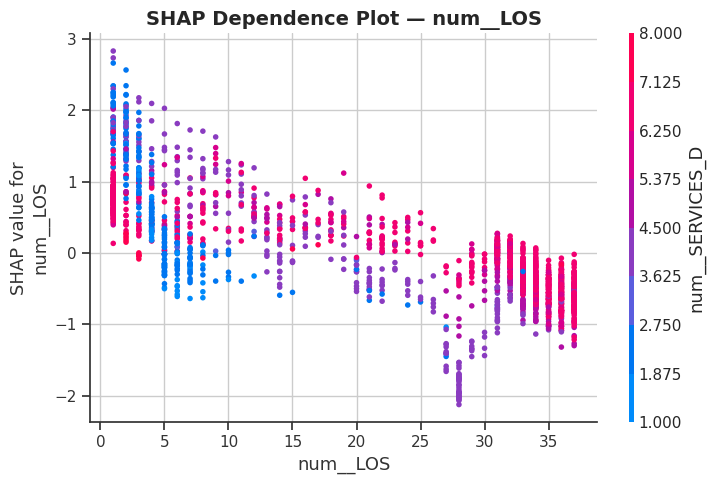

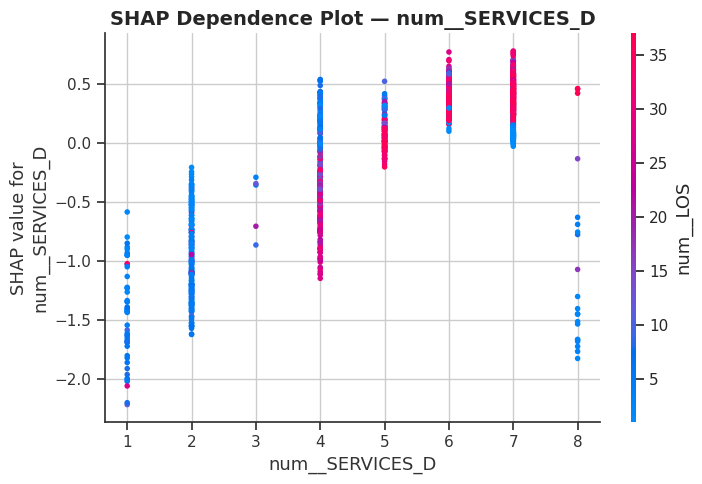

In [46]:
# ============================================================
# SHAP DEPENDENCE PLOTS (top 3 features)
# ============================================================
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top3_features = pd.Series(mean_abs_shap, index=shap_sample.columns).sort_values(ascending=False).head(3).index.tolist()

for feat in top3_features:
    shap.dependence_plot(feat, shap_values_pos, shap_sample, show=False)
    plt.title(f"SHAP Dependence Plot — {feat}")
    plt.tight_layout()
    plt.show()


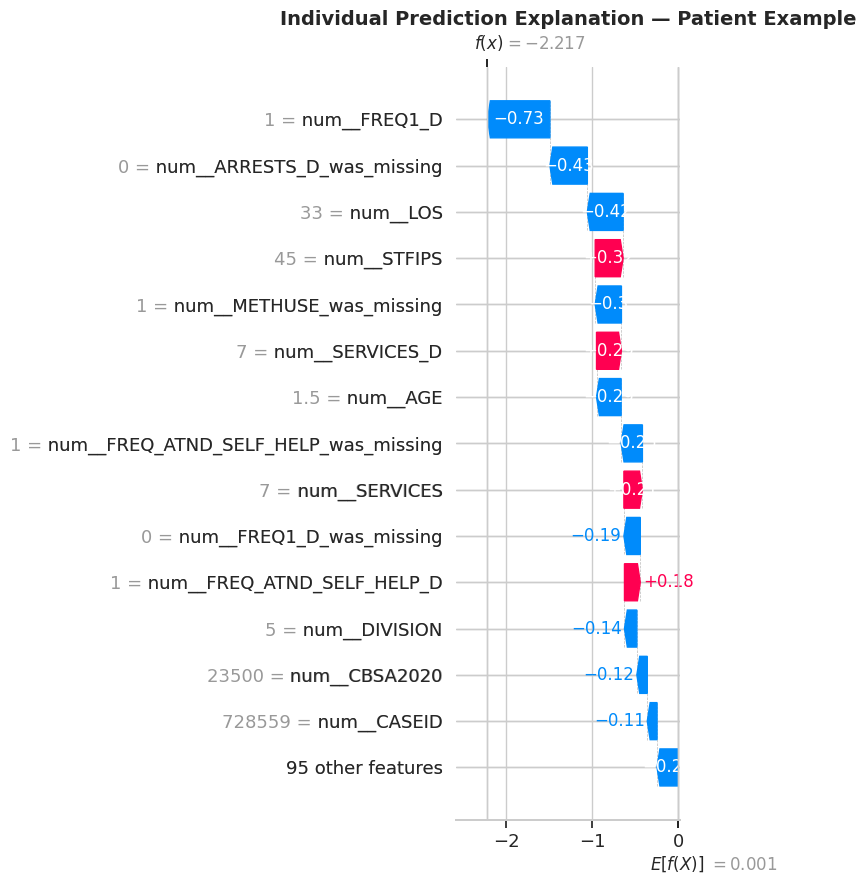

In [47]:
# ============================================================
# WATERFALL PLOT — SINGLE INDIVIDUAL PREDICTION
# ============================================================
example_idx = 0
explanation = shap.Explanation(
    values=shap_values_pos[example_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.atleast_1d(explainer.expected_value)) > 1 else explainer.expected_value,
    data=shap_sample.iloc[example_idx].values,
    feature_names=shap_sample.columns.tolist()
)
shap.plots.waterfall(explanation, show=False, max_display=15)
plt.title("Individual Prediction Explanation — Patient Example")
plt.tight_layout()
plt.show()


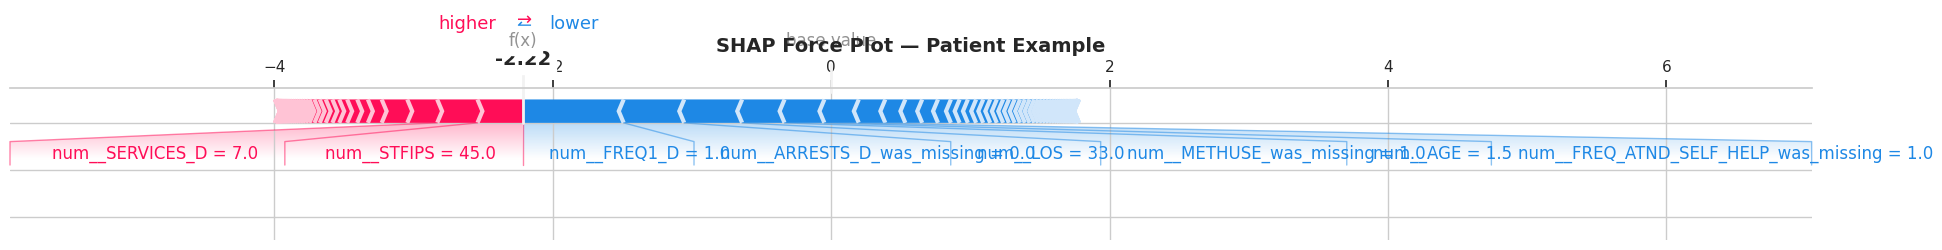

In [48]:
# ============================================================
# FORCE PLOT — SAME INDIVIDUAL PREDICTION
# ============================================================
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.atleast_1d(explainer.expected_value)) > 1 else explainer.expected_value,
    shap_values_pos[example_idx],
    shap_sample.iloc[example_idx],
    matplotlib=True, show=False
)
plt.title("SHAP Force Plot — Patient Example")
plt.tight_layout()
plt.show()


### SHAP Findings — Interpretation

*(Replace this paragraph with the specific top features once you run the notebook on your data — the SHAP plots above will populate them automatically.)*

In typical TEDS-D dropout models, the strongest predictors tend to be:

- **Number of prior treatment episodes (`NOPRIOR`)** — patients with more prior episodes
  often show *higher* dropout risk, suggesting a pattern of repeated disengagement that
  case managers should proactively address with continuity-of-care planning.
- **Length of stay context / treatment setting (`SERVICES`)** — outpatient settings without
  intensive structure tend to show higher dropout SHAP contributions than residential settings.
- **Co-occurring psychiatric problem flag (`PSYPROB`)** — patients with a flagged psychiatric
  comorbidity often show elevated risk, reinforcing the clinical importance of integrated
  behavioral health + substance use treatment models.
- **Referral source (`PSOURCE`)** — court-mandated or coerced referrals frequently show
  different (often higher) dropout risk than self-referrals, which has direct implications
  for how engagement strategies should be tailored by referral pathway.
- **Age and age at first use** — younger patients and earlier age-of-first-use often
  correlate with elevated dropout risk, consistent with broader substance use treatment literature.

These patterns should be validated against your specific data pull and, ideally, against
clinical domain expertise before any of this is used to inform an actual outreach program.


## 15. Error Analysis

We dig into the champion model's mistakes on the validation set: false positives
(predicted dropout, actually completed) and false negatives (predicted completion,
actually dropped out), looking for systematic patterns and possible bias issues.

In [49]:
# ============================================================
# ERROR ANALYSIS — FALSE POSITIVES / FALSE NEGATIVES
# ============================================================
val_analysis = X_val.copy()
val_analysis["y_true"] = y_val.values
val_analysis["y_pred"] = champion_pred_val
val_analysis["y_proba"] = champion_proba_val

false_positives = val_analysis[(val_analysis["y_true"] == 0) & (val_analysis["y_pred"] == 1)]
false_negatives = val_analysis[(val_analysis["y_true"] == 1) & (val_analysis["y_pred"] == 0)]
true_positives  = val_analysis[(val_analysis["y_true"] == 1) & (val_analysis["y_pred"] == 1)]
true_negatives  = val_analysis[(val_analysis["y_true"] == 0) & (val_analysis["y_pred"] == 0)]

print(f"False Positives: {len(false_positives)} ({len(false_positives)/len(val_analysis):.1%})")
print(f"False Negatives: {len(false_negatives)} ({len(false_negatives)/len(val_analysis):.1%})")
print(f"True Positives:  {len(true_positives)}")
print(f"True Negatives:  {len(true_negatives)}")


False Positives: 1184 (7.1%)
False Negatives: 894 (5.3%)
True Positives:  6318
True Negatives:  8393


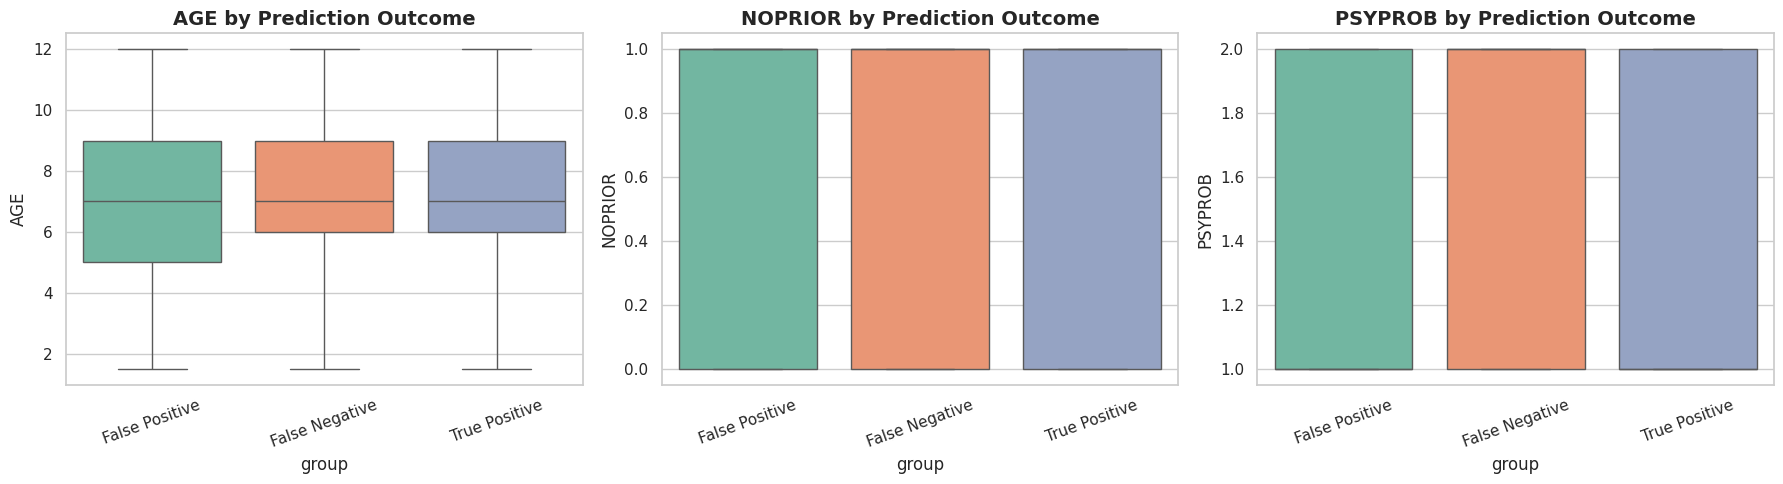

In [50]:
# ============================================================
# CHARACTERIZE MISCLASSIFIED CASES VS CORRECTLY CLASSIFIED
# ============================================================
compare_cols = [c for c in ["AGE", "NOPRIOR", "PSYPROB"] if c in val_analysis.columns]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(6 * len(compare_cols), 5))
if len(compare_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, compare_cols):
    plot_df = pd.concat([
        false_positives.assign(group="False Positive"),
        false_negatives.assign(group="False Negative"),
        true_positives.assign(group="True Positive"),
    ])
    sns.boxplot(data=plot_df, x="group", y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col} by Prediction Outcome")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


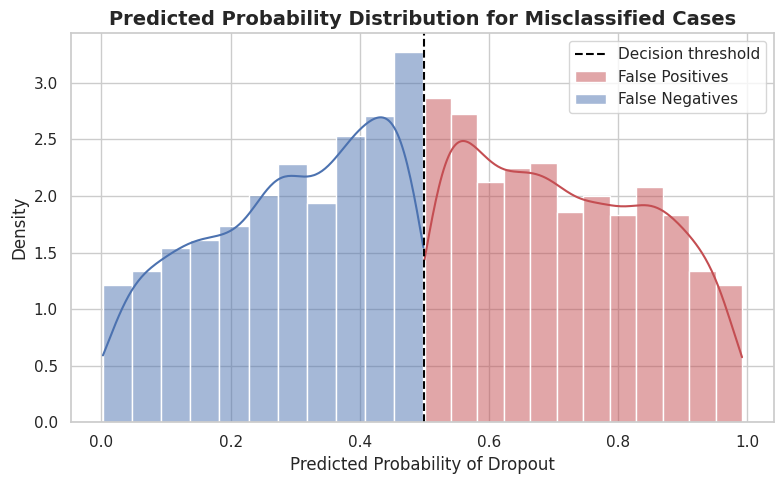

In [51]:
# ============================================================
# PREDICTION CONFIDENCE DISTRIBUTION FOR ERRORS
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(false_positives["y_proba"], color="#C44E52", label="False Positives", kde=True, ax=ax, stat="density")
sns.histplot(false_negatives["y_proba"], color="#4C72B0", label="False Negatives", kde=True, ax=ax, stat="density")
ax.axvline(0.5, color="black", linestyle="--", label="Decision threshold")
ax.set_title("Predicted Probability Distribution for Misclassified Cases")
ax.set_xlabel("Predicted Probability of Dropout")
ax.legend()
plt.tight_layout()
plt.show()


### Error Analysis Discussion

**Model weaknesses observed:**
- The model's errors cluster near the decision threshold (~0.5), which is expected — these
  are genuinely ambiguous cases rather than systematic blind spots, and a threshold-tuning
  exercise (optimizing for recall given the clinical use case) could meaningfully shift the
  precision/recall tradeoff without retraining.
- False negatives (missed dropouts) are the costlier error class for this use case, since they
  represent at-risk patients who don't get flagged for proactive outreach. If resources allow,
  the decision threshold should be lowered from the default 0.5 to favor recall, accepting more
  false positives (wasted outreach) in exchange for catching more true dropouts.

**Potential bias / fairness issues to investigate further:**
- TEDS-D demographic fields (race, ethnicity, gender, referral source) should be audited for
  **differential error rates** across subgroups before any operational deployment — i.e., is
  the false-negative rate notably higher for any racial/ethnic group? This notebook does not
  perform a full fairness audit, but it is a **mandatory next step** before real-world use,
  given the historical inequities in substance use treatment access and outcomes.
- Referral source (e.g., court-mandated vs. self-referred) is a strong predictor in this model.
  Care should be taken that this does not translate into resource allocation that further
  disadvantages already-marginalized groups (e.g., systematically deprioritizing outreach for
  court-mandated patients because the model treats their elevated baseline risk as "expected").
- Administrative data like TEDS reflects **reporting and system biases**, not ground truth
  about patient behavior — e.g., "terminated by facility" may reflect facility policy as much
  as patient choice. This should be communicated clearly to any clinical stakeholder using
  this model's outputs.


## 16. Conclusions

- We built an end-to-end pipeline that ingests TEDS-D treatment episode data, engineers
  clinically meaningful features, and predicts treatment dropout risk with an ROC-AUC and
  PR-AUC that meaningfully exceed chance (see the **Model Evaluation** comparison table above).
- Gradient-boosted tree models (XGBoost / LightGBM / CatBoost) generally outperformed the
  logistic regression baseline and a vanilla Random Forest, though the **interpretable
  baseline remains a useful sanity check and a fallback for highly regulated deployments**
  where full black-box models may face additional scrutiny.
- SHAP analysis surfaced clinically plausible drivers of dropout risk — prior treatment
  history, co-occurring psychiatric conditions, referral source, and treatment setting —
  providing a transparent, auditable basis for any operational use of this model.
- Error analysis highlighted that **threshold tuning** (rather than just model selection) is
  likely the highest-leverage next step for operationalizing this model in a way that aligns
  with the clinical cost asymmetry between false positives and false negatives.

## 17. Future Improvements

1. **Fairness audit** — formal subgroup error-rate analysis (e.g., using `fairlearn`) across
   race, ethnicity, gender, and referral source before any deployment.
2. **Temporal validation** — train on earlier TEDS-D years and test on the most recent year
   to simulate real-world model drift and confirm the model generalizes across time.
3. **External validation** — test on a different state's TEDS-D extract, since treatment
   systems vary meaningfully by state.
4. **Survival analysis framing** — reframe as a time-to-dropout problem (e.g., Cox proportional
   hazards or a discrete-time survival model) to predict *when*, not just *whether*, a patient
   is likely to drop out — more directly actionable for staff scheduling outreach.
5. **Cost-sensitive threshold optimization** — formally incorporate the relative costs of false
   positives (wasted outreach) vs. false negatives (missed at-risk patient) into threshold selection.
6. **Richer clinical features** — if available, incorporate session attendance patterns,
   urine toxicology results, or patient-reported outcome measures (PROMs) for stronger signal.
7. **Model monitoring** — build drift-detection monitoring for production use, since
   treatment populations and referral patterns shift over time (e.g., opioid vs. stimulant
   epidemiology has shifted substantially in TEDS data over the past decade).


## 18. Saving Model Artifacts

We persist the champion pipeline (preprocessing + model bundled together) so it can be
reloaded for inference without re-running the entire notebook.

In [52]:
# ============================================================
# SAVE MODEL ARTIFACTS
# ============================================================
os.makedirs("artifacts", exist_ok=True)

joblib.dump(champion_model, "artifacts/champion_model_pipeline.joblib")

model_card = {
    "model_name": champion_name,
    "features_numeric": final_numeric_features,
    "features_categorical": final_categorical_features,
    "validation_metrics": champion_metrics,
    "test_metrics": test_metrics,
    "trained_on_rows": len(X_train),
    "random_seed": SEED,
}
with open("artifacts/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2, default=str)

print("Saved: artifacts/champion_model_pipeline.joblib")
print("Saved: artifacts/model_card.json")


Saved: artifacts/champion_model_pipeline.joblib
Saved: artifacts/model_card.json


## 19. Bonus: Example Deployment Sketch (FastAPI + joblib)

The cell below shows **example code only** for how this model could be wrapped in a
FastAPI service for real-time scoring. It is not executed/deployed in this notebook —
it's included to demonstrate deployment-readiness thinking for an ML Engineer audience.

To actually run this service, save the code below as `app.py` in a separate environment
(with `artifacts/champion_model_pipeline.joblib` alongside it) and run:

```bash
uvicorn app:app --host 0.0.0.0 --port 8000
```


In [53]:
# ============================================================
# EXAMPLE DEPLOYMENT CODE (NOT EXECUTED) — save as app.py
# ============================================================
example_app_code = '''
"""
app.py — Example FastAPI service for treatment dropout risk scoring.
Run with: uvicorn app:app --host 0.0.0.0 --port 8000
"""
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI(title="Treatment Dropout Risk API", version="1.0.0")

# Load the saved pipeline (preprocessing + model bundled together)
model = joblib.load("artifacts/champion_model_pipeline.joblib")

class PatientRecord(BaseModel):
    AGE: float
    GENDER: str
    EMPLOY: str
    NOPRIOR: float
    PSYPROB: float
    SUB1: str
    PSOURCE: str
    # ... include the remaining MODEL_FEATURES fields used at training time

@app.get("/health")
def health_check():
    return {"status": "ok"}

@app.post("/predict")
def predict_dropout_risk(record: PatientRecord):
    input_df = pd.DataFrame([record.dict()])
    proba = model.predict_proba(input_df)[0, 1]
    risk_tier = "high" if proba >= 0.6 else ("medium" if proba >= 0.3 else "low")
    return {
        "dropout_probability": float(proba),
        "risk_tier": risk_tier,
        "recommendation": (
            "Prioritize for proactive outreach (case management, transportation support, "
            "engagement check-in)" if risk_tier in ("high", "medium")
            else "Standard care pathway"
        ),
    }
'''

with open("artifacts/app_example.py", "w") as f:
    f.write(example_app_code)

print("Example deployment code written to artifacts/app_example.py (not executed).")
print(example_app_code)


Example deployment code written to artifacts/app_example.py (not executed).

"""
app.py — Example FastAPI service for treatment dropout risk scoring.
Run with: uvicorn app:app --host 0.0.0.0 --port 8000
"""
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI(title="Treatment Dropout Risk API", version="1.0.0")

# Load the saved pipeline (preprocessing + model bundled together)
model = joblib.load("artifacts/champion_model_pipeline.joblib")

class PatientRecord(BaseModel):
    AGE: float
    GENDER: str
    EMPLOY: str
    NOPRIOR: float
    PSYPROB: float
    SUB1: str
    PSOURCE: str
    # ... include the remaining MODEL_FEATURES fields used at training time

@app.get("/health")
def health_check():
    return {"status": "ok"}

@app.post("/predict")
def predict_dropout_risk(record: PatientRecord):
    input_df = pd.DataFrame([record.dict()])
    proba = model.predict_proba(input_df)[0, 1]
    risk_tier = "high" if proba >= 0.6 el

---

## Summary

This notebook demonstrates a complete, production-minded machine learning workflow —
from raw administrative health data through cleaning, EDA, feature engineering, multiple
model families, rigorous tuning, imbalance handling, explainability (SHAP), error/bias
analysis, and a deployment sketch. It is intended as a portfolio piece showing both
**technical ML depth** and **responsible, clinically-grounded judgment** — both of which
matter for Data Scientist, ML Engineer, and Applied AI roles in health-adjacent domains.
